# EverFlavor AI - Cooking Methods and Cooking Fats

**Team:** EverGlow
**Course:** ITAI 2277
**Project:** EverFlavor AI - Multi-Agent Recipe and Nutrition System

---

## Purpose

Notebook 01 records **what** goes into each recipe. This notebook adds **how it is cooked** and **which fat it is cooked in**:

- **Safety:** a fried dish whose oil is not stated may be cooked in peanut oil, sesame oil, lard or beef tallow. The Chef and Nutritionist agents must warn about that instead of assuming the dish is safe.
- **Flavor:** the cooking fat changes how a dish tastes (ghee is nutty, mustard oil is sharp, canola is neutral). The agents can suggest the traditional fat, or a substitute, and explain the difference.
- **Restaurants and stores (later):** no open data says which oil a restaurant uses, so any oil claim from the Sourcing Agent stays **"unverified, ask the restaurant"** unless a published menu or allergen sheet confirms it.

**Safety rule:** the labels in this notebook can **add** a caution, but never **clear** a restriction flag from notebook 01. Guesses about the fat are recommendations, never facts.

## Inputs and outputs

| | File | Made by |
|---|---|---|
| Input | `data/processed/recipes_{train,val,test}.parquet` | Notebook 01 (section 5.11) |
| Input | Food.com `RAW_recipes.csv` (its tags) | Notebook 01 (section 2.4.2), reused from the kagglehub cache |
| Input | USDA SR Legacy bulk download | Notebook 01 (section 5.8), downloaded here if missing |
| Input | `data/reference/cooking_fats.csv` | This project (in GitHub) |
| Output | `data/processed/cooking_fats_reference.csv` | Section 2 |
| Output | `data/interim/recipe_cooking_labels.parquet` | Section 6 |

**Run notebook 01 first** (in the same Colab session, or on the same computer): its processed files are not stored in GitHub.

## Contents

1. Setup
2. Reference Table of Cooking Fats
3. Cooking Methods: Rules and Food.com Tags
4. Cooking Fats in the Recipes
5. Alcohol Left After Cooking
6. Save the Labels
7. Next Steps: the Two Models

---

## 1. Setup

The same setup as notebook 01: it works unchanged in Google Colab, VS Code and Antigravity. Run these cells first, and again after every kernel restart.

In [1]:
# %pip (not !pip) installs into the Python that runs this notebook,
# in Colab and in local kernels (VS Code / Antigravity / JupyterLab).
%pip install -q kagglehub requests pandas pyarrow matplotlib seaborn scikit-learn tqdm ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
from pathlib import Path

# -------------------------------------------------------
# 1. Where is this notebook running? Move to the project folder
#    (the one that holds notebooks/ and data/), as in notebook 01.
# -------------------------------------------------------
try:
    import google.colab  # noqa: F401  # pyright: ignore[reportMissingImports]  (only exists in Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def find_project_root(start):
    # Return the nearest folder at or above `start` with notebooks/ and data/, or None
    start = Path(start).resolve()
    for folder in [start, *start.parents]:
        if (folder / "notebooks").is_dir() and (folder / "data").is_dir():
            return folder
    return None

PROJECT_ROOT = find_project_root(Path.cwd())
if PROJECT_ROOT is None and IN_COLAB and Path("/content/The-EverFlavor-AI").is_dir():
    PROJECT_ROOT = Path("/content/The-EverFlavor-AI")
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)

# -------------------------------------------------------
# 2. The project's code (src/everflavor). If the notebook was opened on its
#    own, the missing files are downloaded from GitHub (temporary name
#    first, __init__.py last), exactly as in notebook 01.
# -------------------------------------------------------
SRC_DIR = PROJECT_ROOT / "src"
EVERFLAVOR_MODULES = ["__init__", "checks", "environment", "charts", "sources", "parsing", "cuisine",
                      "ingredients", "flags", "diets", "nutrition", "features", "pipeline", "review",
                      "recommend", "reporting", "cooking"]
EVERFLAVOR_URL = "https://raw.githubusercontent.com/Chloe-Tu2/The-EverFlavor-AI/main/src/everflavor/"
EVERFLAVOR_DIR = SRC_DIR / "everflavor"
missing_modules = [m for m in EVERFLAVOR_MODULES if not (EVERFLAVOR_DIR / f"{m}.py").exists()]
if missing_modules:
    import urllib.request
    EVERFLAVOR_DIR.mkdir(parents=True, exist_ok=True)
    for module in sorted(missing_modules, key=lambda m: m == "__init__"):
        partial = EVERFLAVOR_DIR / f"{module}.py.part"
        urllib.request.urlretrieve(f"{EVERFLAVOR_URL}{module}.py", partial)
        partial.replace(EVERFLAVOR_DIR / f"{module}.py")
    print(f"Downloaded {len(missing_modules)} project code file(s) (src/everflavor) from GitHub.")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from everflavor.environment import short_path

# -------------------------------------------------------
# 3. Inputs from notebook 01. The reference table is in GitHub; if the notebook
#    was opened on its own, it is downloaded like the code.
# -------------------------------------------------------
REFRESH_DOWNLOADS = False   # True downloads the USDA file again
SPLIT_FILES = {s: Path(f"data/processed/recipes_{s}.parquet") for s in ["train", "val", "test"]}
REFERENCE_FILE = Path("data/reference/cooking_fats.csv")
if not REFERENCE_FILE.exists():
    import urllib.request
    REFERENCE_FILE.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/Chloe-Tu2/The-EverFlavor-AI/main/data/reference/cooking_fats.csv",
        REFERENCE_FILE)
for folder in ["data/raw/usda_fdc", "data/interim", "data/processed"]:
    os.makedirs(folder, exist_ok=True)

print(f"Runtime        : {'Google Colab' if IN_COLAB else 'Local Jupyter (VS Code / Antigravity / JupyterLab)'}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Project folder : {short_path(PROJECT_ROOT)}")
missing_inputs = [str(p) for p in SPLIT_FILES.values() if not p.exists()]
if missing_inputs:
    print("\nMISSING notebook 01 outputs:", ", ".join(missing_inputs))
    print("Run notebook 01 first (all of Week 5), then run this notebook again.")
else:
    print("Notebook 01 outputs found: the recipe splits are ready.")

Runtime        : Local Jupyter (VS Code / Antigravity / JupyterLab)
Python         : 3.12.10
Project folder : ~\Downloads\jupiter-exploration\The-EverFlavor-AI
Notebook 01 outputs found: the recipe splits are ready.


In [3]:
# One chart style for both notebooks (src/everflavor/charts.py);
# charts are shown here and saved to data/processed/figures/
import matplotlib.pyplot as plt
import pandas as pd

from everflavor.charts import (
    FAMILY_ORDER,
    SOURCE_LABELS,
    label_bars,
    set_chart_style,
    show_figure,
    thousands,
)

set_chart_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 60)
print("Chart style set.")

Chart style set.


---

## 2. Reference Table of Cooking Fats

`data/reference/cooking_fats.csv` describes 31 cooking fats: what kind of fat each is, the animal it comes from (for diets), the allergen it can carry, its flavor, what it is best for, its smoke point and where it is traditional. The last row, `oil_unspecified`, stands for recipes that say only "oil".

| Column | Source |
|---|---|
| `smoke_point_c_low`, `smoke_point_c_high` | The smoke point table on Wikipedia ("Smoke point"), which cites food-science sources such as *The Professional Chef* (Culinary Institute of America, 2011) and Gunstone, *Vegetable Oils in Food Technology* (2011). Values are a **range** because refined and unrefined oils differ; fats with no value in that table are left empty instead of guessed. |
| Fat breakdown (saturated, mono- and polyunsaturated, g per 100 g) | USDA FoodData Central, SR Legacy (official), joined on `usda_fdc_id` below |
| `allergen`, `notes` on refined oils | FDA, Food Allergen Labeling and Consumer Protection Act (FALCPA): highly refined oils are exempt from allergen labeling. We still warn, because cold-pressed oils are not refined. |
| `animal_source`, `flavor`, `best_for`, `traditional_in` | Written by the team from general culinary references. **To be spot-checked by the team**, like the restriction flags. |

The fat breakdown is read from the USDA bulk download that notebook 01 already uses (downloaded here if it is missing; no API key needed).

In [4]:
from everflavor.cooking import FAT_NUTRIENTS, fat_reference
from everflavor.sources import usda_table

reference_raw = pd.read_csv(REFERENCE_FILE)
sr_legacy = usda_table("sr_legacy", "data/raw/usda_fdc", refresh=REFRESH_DOWNLOADS, nutrients=FAT_NUTRIENTS)
fats_ref = fat_reference(reference_raw, sr_legacy)

FAT_REFERENCE_OUT = "data/processed/cooking_fats_reference.csv"
fats_ref.to_csv(FAT_REFERENCE_OUT, index=False)

print(f"{len(fats_ref)} cooking fats; USDA fat breakdown found for "
      f"{fats_ref['saturated_g_100g'].notna().sum()} of {fats_ref['usda_fdc_id'].notna().sum()} with a USDA id")
print(f"Saved to {FAT_REFERENCE_OUT}\n")
print(fats_ref[["fat_id", "kind", "animal_source", "allergen", "smoke_point_c_low", "smoke_point_c_high",
                "saturated_g_100g", "mono_g_100g", "poly_g_100g"]].fillna("").to_string(index=False))

31 cooking fats; USDA fat breakdown found for 30 of 30 with a USDA id
Saved to data/processed/cooking_fats_reference.csv

         fat_id            kind                                 animal_source                allergen smoke_point_c_low smoke_point_c_high saturated_g_100g mono_g_100g poly_g_100g
      olive_oil       plant oil                                                                                   190.0              243.0             13.8        73.0        10.5
     canola_oil       plant oil                                                                                   190.0              232.0             7.36        63.3        28.1
  vegetable_oil plant oil blend                                                            may be soy             220.0              220.0             15.6        22.8        57.7
    soybean_oil       plant oil                                                                   soy             234.0              234.0             15.6   

### 2.1 Fat breakdown and smoke points

Left: what each fat is made of, from USDA. Right: the smoke point range (where the fat starts to smoke and break down). For deep-frying (about 175-190 °C), a fat should smoke well above that temperature.

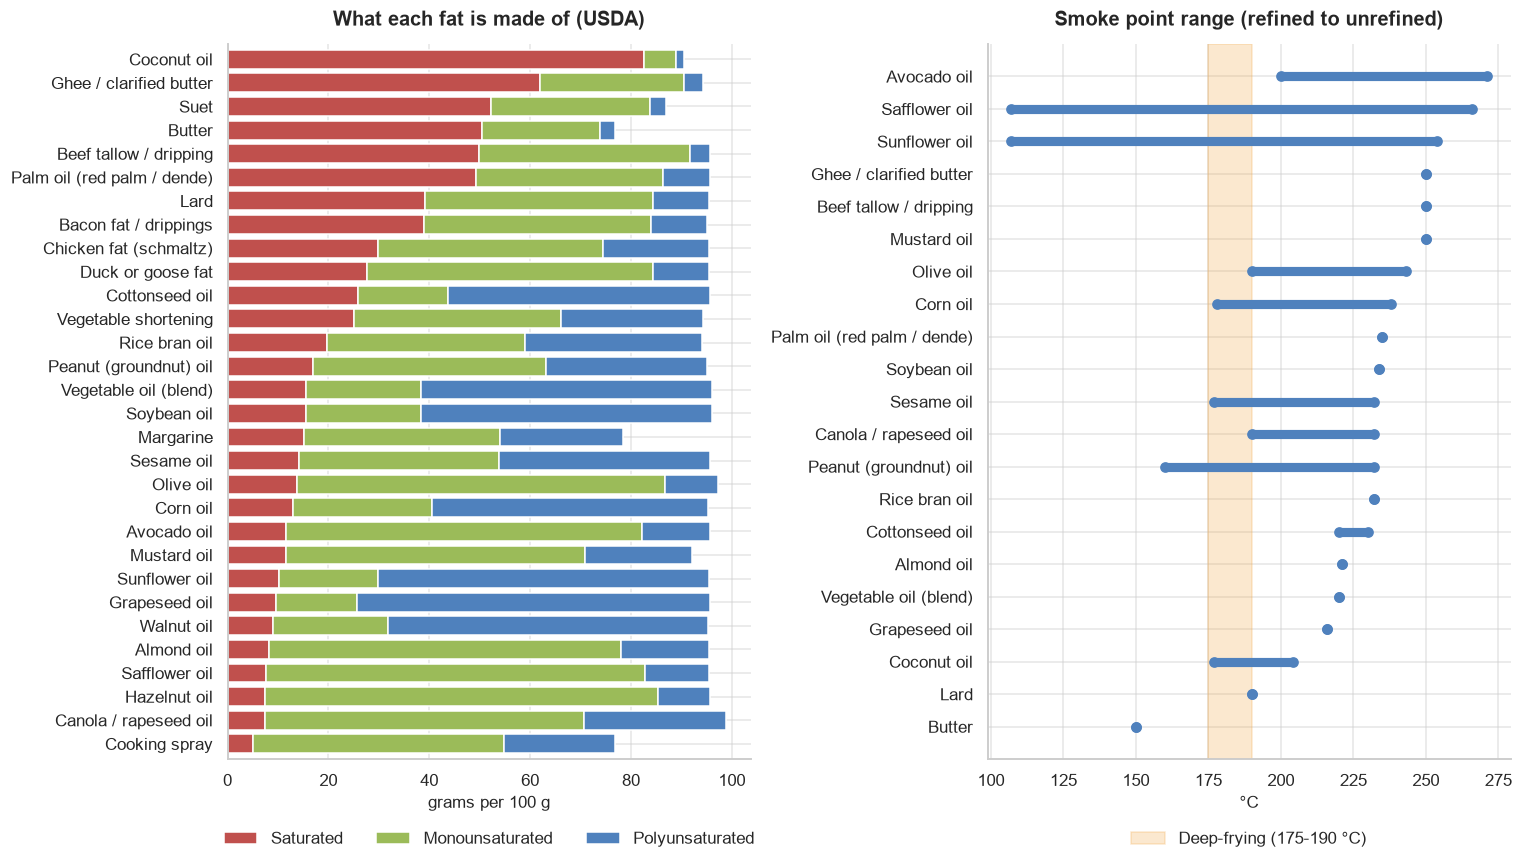

In [5]:
fat_parts = {"saturated_g_100g": "Saturated", "mono_g_100g": "Monounsaturated", "poly_g_100g": "Polyunsaturated"}
plot_df = (fats_ref.dropna(subset=["saturated_g_100g"]).set_index("name")[list(fat_parts)]
           .rename(columns=fat_parts).sort_values("Saturated"))
smoke = (fats_ref.dropna(subset=["smoke_point_c_low"]).set_index("name")
         [["smoke_point_c_low", "smoke_point_c_high"]].sort_values("smoke_point_c_high"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
plot_df.plot.barh(stacked=True, ax=ax1, color=["#c0504d", "#9bbb59", "#4f81bd"], width=0.8)
ax1.set_title("What each fat is made of (USDA)")
ax1.set_xlabel("grams per 100 g")
ax1.set_ylabel("")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)

ax2.hlines(smoke.index, smoke["smoke_point_c_low"], smoke["smoke_point_c_high"], color="#4f81bd", linewidth=6)
ax2.plot(smoke["smoke_point_c_low"], smoke.index, "o", color="#4f81bd")
ax2.plot(smoke["smoke_point_c_high"], smoke.index, "o", color="#4f81bd")
ax2.axvspan(175, 190, color="#f2a541", alpha=0.25, label="Deep-frying (175-190 °C)")
ax2.set_title("Smoke point range (refined to unrefined)")
ax2.set_xlabel("°C")
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08))
show_figure(fig, "nb02_01_fats_reference")

**What this shows**

- **Most saturated:** coconut oil, ghee, butter, beef tallow, palm oil and lard. **Least saturated:** canola, safflower and hazelnut oil. The Nutritionist Agent can use this when someone asks for a lighter swap.
- **Butter** smokes far below frying temperature, which is why recipes fry in ghee (clarified butter) or oil instead.
- **Unrefined** sunflower, safflower and peanut oil smoke at or below frying temperature, while their **refined** versions are fine for it. The wide bars show why a recipe that just says "sunflower oil" is not enough to judge.

---

## 3. Cooking Methods: Rules and Food.com Tags

Each recipe gets cooking methods from two independent sources:

1. **Rules on the instructions** (`methods_from_instructions`): words such as "deep-fry", "drop by spoonfuls into hot oil", "bake", "simmer". "No cook" means the instructions mention no heat at all. Only Food.com and TheMealDB have instructions.
2. **Food.com tags** (`methods_from_tags`): tags such as `deep-fry`, `oven` and `no-cook`, added by the person who posted the recipe. They are human labels, but optional: a missing tag does not mean the method is absent.

A third signal works for every source: **the recipe name** (`fried_by_name`), for dishes that are fried by definition (fritters, samosas, tempura, falafel ...), unless the name says "oven-fried", "air fryer" or "baked".

The Food.com tags are read from the kagglehub cache that notebook 01 filled (nothing is downloaded again).

In [6]:
import ast

import kagglehub

from everflavor.cooking import COOKING_METHODS, add_cooking_labels

recipes = pd.concat([pd.read_parquet(path) for path in SPLIT_FILES.values()], ignore_index=True)

foodcom_path = Path(kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions"))
foodcom_raw = pd.read_csv(foodcom_path / "RAW_recipes.csv", usecols=["id", "tags"])
foodcom_tags = dict(zip("foodcom_" + foodcom_raw["id"].astype(str), foodcom_raw["tags"].apply(ast.literal_eval)))

labels = add_cooking_labels(recipes, foodcom_tags)
print(f"{len(labels):,} recipes labeled\n")

coverage = labels.groupby("source").agg(
    recipes=("recipe_id", "size"),
    with_instructions=("has_instructions", "mean"),
    with_foodcom_tags=("has_tags", "mean"),
    fried_by_name=("fried_by_name", "mean"),
)
coverage.index = coverage.index.map(SOURCE_LABELS)
print(coverage.to_string(formatters={"recipes": "{:,}".format, "with_instructions": "{:.1%}".format,
                                     "with_foodcom_tags": "{:.1%}".format, "fried_by_name": "{:.1%}".format}))

Cooking methods from the steps:   0%|          | 0/291755 [00:00<?, ?it/s]

291,755 recipes labeled

             recipes with_instructions with_foodcom_tags fried_by_name
source                                                                
CulinaryDB    35,325              0.0%              0.0%          2.8%
Food.com     218,024             93.9%            100.0%          1.7%
Hugging Face  37,823              0.0%              0.0%          2.3%
TheMealDB        583             96.4%              0.0%          4.1%


### 3.1 How often each method appears

               From instructions  From Food.com tags
deep_fry                    4196                1027
pan_fry                    51305                   0
stir_fry                    4594                1622
bake_roast                 97450               28965
grill_broil                17047                5692
boil_simmer                63428                   0
steam                       3701                 413
slow_cook                   7199                6253
pressure_cook                387                 304
microwave                   8683                2031
smoke                        209                 129
no_cook                    29456                5751


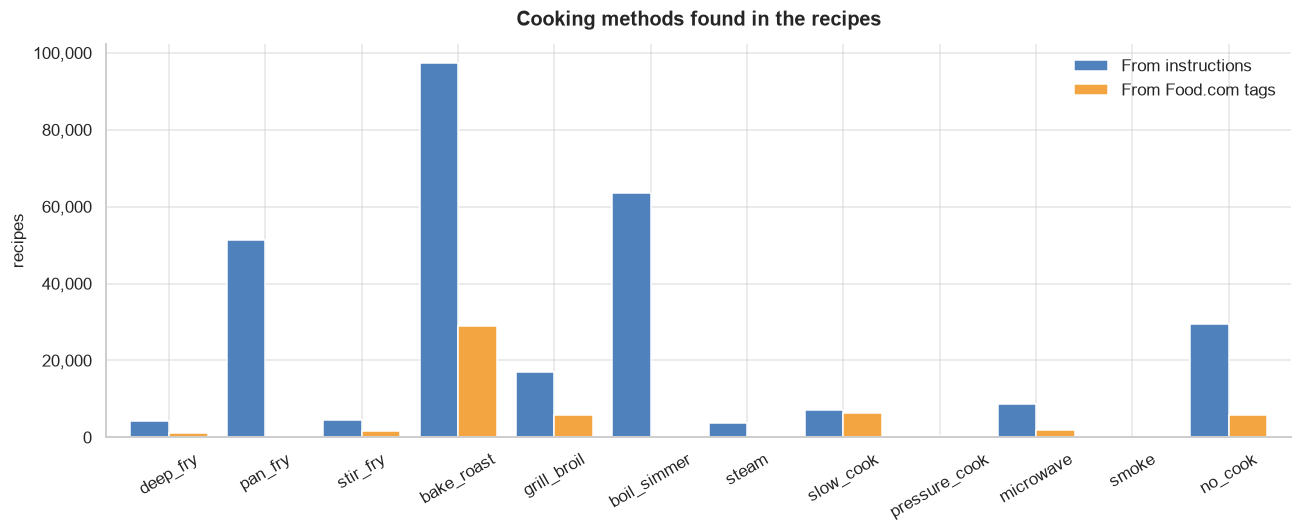

In [7]:
method_counts = pd.DataFrame({
    "From instructions": labels["methods_instructions"].explode().value_counts(),
    "From Food.com tags": labels["methods_tags"].explode().value_counts(),
}).reindex(COOKING_METHODS).fillna(0).astype(int)
print(method_counts.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
method_counts.plot.bar(ax=ax, color=["#4f81bd", "#f2a541"], width=0.8)
ax.set_title("Cooking methods found in the recipes")
ax.set_xlabel("")
ax.set_ylabel("recipes")
ax.tick_params(axis="x", rotation=30)
thousands(ax)
show_figure(fig, "nb02_02_method_counts")

### 3.2 Do the rules agree with the people who tagged the recipes?

Only recipes with **both** instructions and tags are compared (Food.com). The main check is **`rule_finds_tag`**: of the recipes a person tagged with a method, how many the rules also find. `tag_confirms_rule` is low by design: tags are optional, so many recipes the rules find were simply never tagged (for example, salads and drinks that the rules call "no cook" but nobody tagged).

               tagged   rule   both rule_finds_tag tag_confirms_rule
method                                                              
deep_fry         1008   4140    737            73%               18%
stir_fry         1586   4558   1185            75%               26%
bake_roast      28796  97204  27031            94%               28%
grill_broil      5586  16986   5181            93%               31%
steam             404   3675    321            79%                9%
slow_cook        6129   7195   5828            95%               81%
pressure_cook     284    380    232            82%               61%
microwave        1952   8674   1830            94%               21%
smoke             128    205     84            66%               41%
no_cook          5149  29426   4585            89%               16%


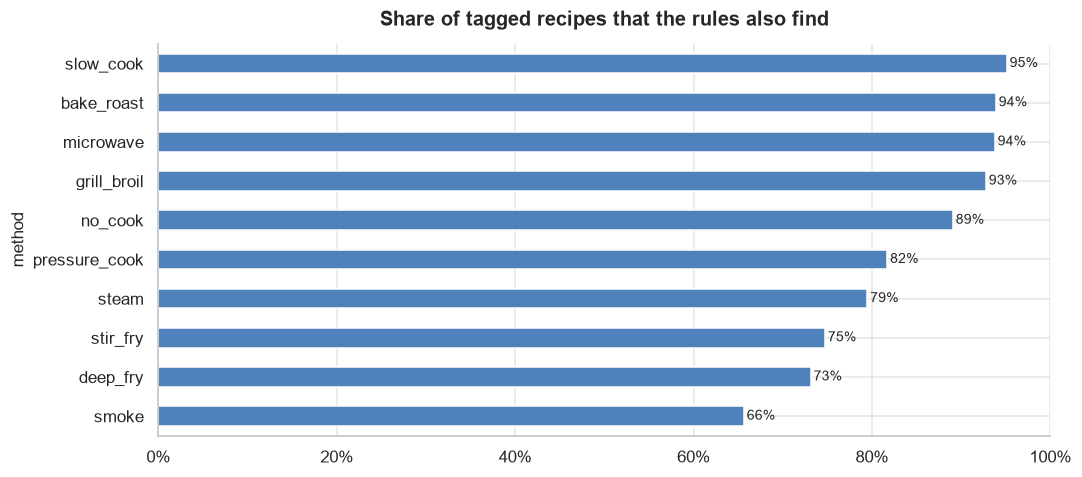

In [8]:
from everflavor.cooking import method_label_agreement

agreement = method_label_agreement(labels)
print(agreement.to_string(formatters={"rule_finds_tag": "{:.0%}".format, "tag_confirms_rule": "{:.0%}".format}))

fig, ax = plt.subplots(figsize=(10, 4.5))
agreement["rule_finds_tag"].sort_values().plot.barh(ax=ax, color="#4f81bd")
ax.set_title("Share of tagged recipes that the rules also find")
ax.set_xlabel("")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
label_bars(ax, fmt="{:.0%}")
show_figure(fig, "nb02_03_rule_vs_tags")

**What this shows**

- The rules find **89-95%** of the recipes tagged as baked or roasted, grilled, slow-cooked, microwaved or no-cook, and **80-82%** of the steamed and pressure-cooked ones.
- They are weakest on **deep-frying (73%)**, **stir-frying (75%)** and **smoking (66%)**: these instructions often describe the step without the word ("heat oil in a deep pan, add the dough ... until golden").
- So neither source is complete on its own. The **cooking-method model** (section 7) trains on both, plus the recipe name and ingredients, so it can also label the CulinaryDB and Hugging Face recipes, which have no instructions.

---

## 4. Cooking Fats in the Recipes

`fats_from_ingredients` maps each ingredient to one fat of the reference table ("extra virgin olive oil" to `olive_oil`, "clarified butter" to `ghee`). Phrases such as "peanut butter", "butter beans" or "tuna in olive oil" are not counted as cooking fats. An ingredient that says only "oil" becomes `oil_unspecified`.

Each recipe then falls into one group:

| Group | Meaning |
|---|---|
| Specific fat | At least one fat with a known source (olive oil, butter, lard ...) |
| Blend only | Only "vegetable oil" or cooking spray: plant-based, but which plant is unknown |
| Only "oil" | The type of oil is not stated |
| No fat listed | No cooking fat in the ingredients |

fat_status    Specific fat  Blend only  Only "oil"  No fat listed
source                                                           
CulinaryDB           62.1%        8.0%        0.2%          29.7%
Food.com             51.1%        5.6%        3.9%          39.4%
Hugging Face         53.0%        4.5%        2.6%          39.8%
TheMealDB            54.4%       12.7%        5.1%          27.8%


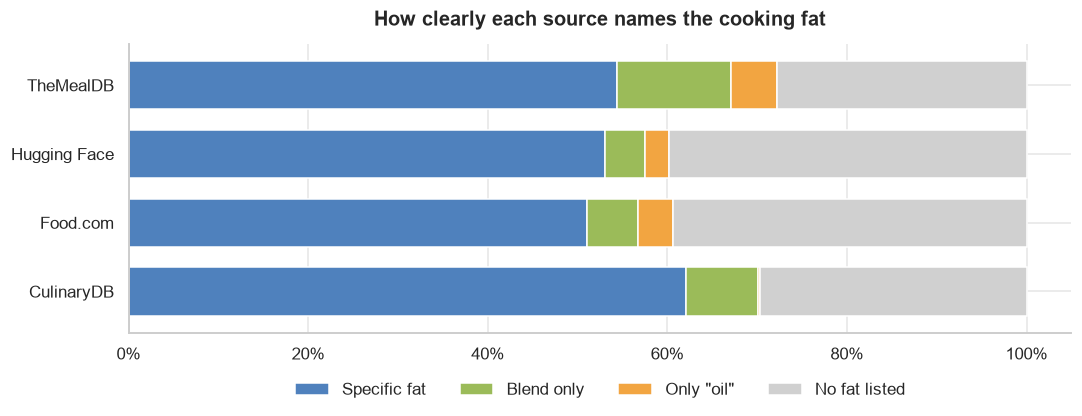

In [9]:
from everflavor.cooking import SPECIFIC_FATS


def fat_status(fats):
    # Group a recipe by the most specific fat it lists
    if any(f in SPECIFIC_FATS for f in fats):
        return "Specific fat"
    if fats and any(f != "oil_unspecified" for f in fats):
        return "Blend only"
    if "oil_unspecified" in fats:
        return 'Only "oil"'
    return "No fat listed"

FAT_STATUS_ORDER = ["Specific fat", "Blend only", 'Only "oil"', "No fat listed"]
labels["fat_status"] = labels["cooking_fats"].apply(fat_status)
status_by_source = (pd.crosstab(labels["source"].map(SOURCE_LABELS), labels["fat_status"], normalize="index")
                    [FAT_STATUS_ORDER])
print(status_by_source.to_string(float_format="{:.1%}".format))

fig, ax = plt.subplots(figsize=(10, 4))
status_by_source.plot.barh(stacked=True, ax=ax, color=["#4f81bd", "#9bbb59", "#f2a541", "#d0d0d0"], width=0.7)
ax.set_title("How clearly each source names the cooking fat")
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
show_figure(fig, "nb02_04_fat_status_by_source")

**What this shows:** about half of the recipes in every source (51-62%) name a specific fat. Another 5-13% use a blend ("vegetable oil", cooking spray), and only 0-5% say just "oil". The 28-40% with no fat listed are mostly salads, drinks, sauces and baked goods made without butter or oil.

### 4.1 The most-used fats by cuisine family and by country

Shares are out of the recipes that list a fat (other than plain "oil"); a recipe can list more than one fat, so the shares can add up to more than 100%. Countries with at least 100 such recipes are shown. These are the fats **recipe writers** use, mostly on English-language sites, which is not always the traditional fat (see the limits in section 7).

In [10]:
from everflavor.cooking import top_fats_by_group

by_family = top_fats_by_group(labels, "cuisine_family")
by_family["cuisine_family"] = pd.Categorical(by_family["cuisine_family"], FAMILY_ORDER)
print(by_family.sort_values("cuisine_family").to_string(index=False))
print()
by_country = top_fats_by_group(labels, "origin_country", min_recipes=100)
print(by_country[by_country["origin_country"] != "Unknown"].to_string(index=False))

cuisine_family  recipes_with_fat                                           top_fats
       African              2144     olive_oil 59% | butter 27% | vegetable_oil 11%
Middle Eastern              2359     olive_oil 66% | butter 21% | vegetable_oil 11%
Latin American              7801     olive_oil 46% | butter 24% | vegetable_oil 21%
         Asian             13095 vegetable_oil 26% | sesame_oil 26% | olive_oil 14%
      European             33602      olive_oil 56% | butter 42% | vegetable_oil 7%
         Other            111602     butter 53% | olive_oil 29% | vegetable_oil 11%



origin_country  recipes_with_fat                                            top_fats
 United States             72220      butter 57% | olive_oil 23% | vegetable_oil 12%
         Italy             18018       olive_oil 76% | butter 30% | vegetable_oil 4%
        Mexico              6759      olive_oil 45% | vegetable_oil 22% | butter 22%
        France              5969       butter 61% | olive_oil 38% | vegetable_oil 7%
         India              4828    sunflower_oil 27% | vegetable_oil 20% | ghee 20%
         China              4200 sesame_oil 51% | vegetable_oil 29% | peanut_oil 18%
        Greece              3389       olive_oil 81% | butter 21% | vegetable_oil 3%
United Kingdom              2970       butter 71% | olive_oil 16% | vegetable_oil 7%
        Canada              2778      butter 55% | olive_oil 24% | vegetable_oil 13%
     Australia              1608       butter 52% | olive_oil 41% | vegetable_oil 5%
         Spain              1389       olive_oil 85% | butter 15%

**What this shows**

- **Clear regional patterns:** olive oil leads in the Mediterranean (Spain 85%, Lebanon 82%, Greece 81%, Morocco 80%, Italy 76%). Sesame oil leads in Korea (78%), China (51%) and Japan (42%). Butter leads in Northern Europe, the UK, Ireland and the US.
- **Peanut oil** is in the top three for China, Vietnam and Indonesia, which is where an unnamed "oil" most needs a peanut warning.
- **Where the data and tradition differ:** India's top fat here is sunflower oil, and mustard oil does not appear in the top three. Mexico's top fat is olive oil rather than lard. These recipes were written for home cooks outside those countries. The likely-fat model will learn from these numbers, so the reference table's `traditional_in` column is what lets the agents also say "traditionally made with ghee / mustard oil / lard".

### 4.2 Fried recipes: is the frying fat known?

A recipe counts as fried when its name, its Food.com tags or its instructions say so. `frying_fat_unknown` marks fried recipes that name no specific fat: these are the ones where the agents must say "frying oil not stated".

              fried recipes  frying fat unknown share unknown
source                                                       
CulinaryDB             1003                 404           40%
Food.com               6757                3495           52%
Hugging Face            878                 369           42%
TheMealDB                67                  38           57%

All sources: 8,705 fried recipes, 4,306 (49%) without a specific fat


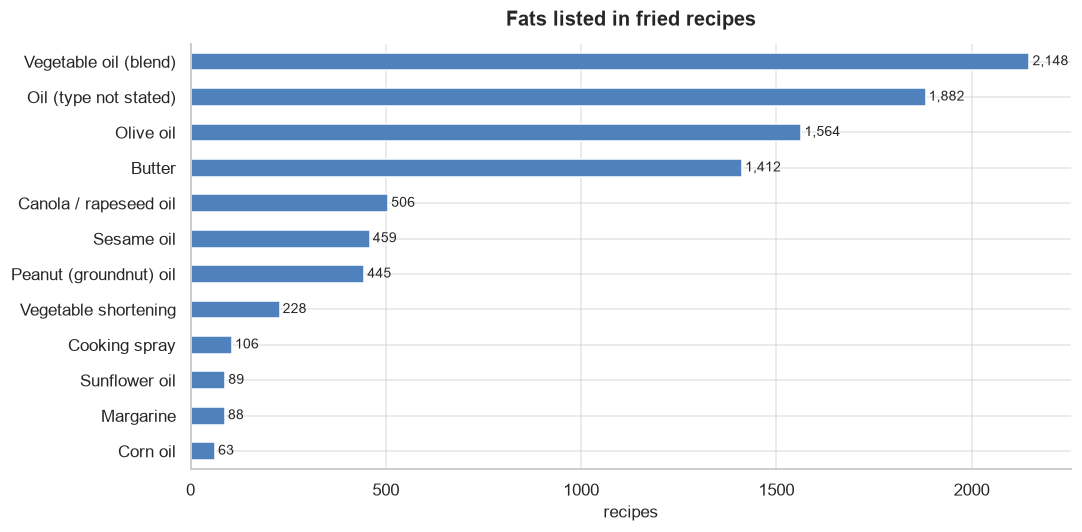

In [11]:
fried = (labels["fried_by_name"]
         | labels["methods_tags"].apply(lambda m: "deep_fry" in m)
         | labels["methods_instructions"].apply(lambda m: "deep_fry" in m))
fried_summary = pd.DataFrame({
    "fried recipes": fried.groupby(labels["source"]).sum(),
    "frying fat unknown": labels.groupby("source")["frying_fat_unknown"].sum(),
})
fried_summary["share unknown"] = fried_summary["frying fat unknown"] / fried_summary["fried recipes"]
fried_summary.index = fried_summary.index.map(SOURCE_LABELS)
print(fried_summary.to_string(formatters={"share unknown": "{:.0%}".format}))
print(f"\nAll sources: {fried.sum():,} fried recipes, {labels['frying_fat_unknown'].sum():,} "
      f"({labels['frying_fat_unknown'].sum() / fried.sum():.0%}) without a specific fat")

fat_names = fats_ref.set_index("fat_id")["name"]
fried_fats = labels.loc[fried, "cooking_fats"].explode().value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 5))
fried_fats.rename(fat_names).sort_values().plot.barh(ax=ax, color="#4f81bd")
ax.set_title("Fats listed in fried recipes")
ax.set_xlabel("recipes")
ax.set_ylabel("")
label_bars(ax)
show_figure(fig, "nb02_05_fried_fats")

**What this shows:** about **half of the fried recipes (49%) do not name a specific frying fat**. Most say "vegetable oil" or just "oil", or list no fat at all. For these recipes the agents must say "frying oil not stated" and must not assume the dish is free of peanut, sesame or animal fat. Peanut oil is named in about 450 fried recipes, and sesame oil in about 460 (mostly stir-fries).

---

## 5. Alcohol Left After Cooking

Cooking does **not** remove all alcohol. The USDA Table of Nutrient Retention Factors (Release 6, 2007) measured how much stays:

| How the alcohol is cooked | Alcohol left |
|---|---|
| Added to boiling liquid, then taken off the heat | 85% |
| Flamed (flambé) | 75% |
| No heat, stored overnight | 70% |
| Baked or simmered, stirred in: 15 / 30 minutes | 40% / 35% |
| 1 hour / 1.5 hours / 2 hours / 2.5 hours | 25% / 20% / 10% / 5% |

For every recipe with alcohol or an alcohol-based flavor extract (`contains_alcohol`, `contains_alcohol_extract` from notebook 01), `add_alcohol_estimate` gives a **range**: a recipe rarely says when the alcohol goes in, so the low end assumes it cooked the whole time and the high end that it was added at the end. A recipe's time includes preparation, so the low end can be too low.

**Information only:** the estimate never clears an alcohol flag. For halal, pregnancy, children and people who avoid alcohol, any amount can matter (policy P18). Notebook 04 will suggest alcohol-free swaps.

In [12]:
from everflavor.cooking import add_alcohol_estimate

labels = add_alcohol_estimate(labels)
with_alcohol = labels["alcohol_left_max"].notna()
print(f"Recipes with alcohol or an alcohol-based extract: {with_alcohol.sum():,} of {len(labels):,} "
      f"({with_alcohol.mean():.1%})")

alcohol = labels.loc[with_alcohol]
estimate = (alcohol["alcohol_left_min"].mul(100).round().astype(int).astype(str) + "-"
            + alcohol["alcohol_left_max"].mul(100).round().astype(int).astype(str) + "% left")
summary = estimate.value_counts().to_frame("recipes")
summary["share (%)"] = (summary["recipes"] / len(alcohol) * 100).round(1)
print("\nEstimated alcohol left (most common ranges):")
print(summary.head(10).to_string())
print(f"\nAt least 25% may be left in {(alcohol['alcohol_left_min'] >= 0.25).mean():.0%} of these recipes; "
      f"none of them can be called alcohol-free.")

Recipes with alcohol or an alcohol-based extract: 63,671 of 291,755 (21.8%)

Estimated alcohol left (most common ranges):
              recipes  share (%)
70-100% left    24491       38.5
25-85% left     14712       23.1
35-85% left      8756       13.8
20-85% left      6697       10.5
5-85% left       4631        7.3
40-85% left      2581        4.1
10-85% left      1775        2.8
35-75% left        10        0.0
40-75% left         8        0.0
25-75% left         7        0.0

At least 25% may be left in 79% of these recipes; none of them can be called alcohol-free.


**Chart: the least alcohol each recipe can keep.** One bar per USDA row: the low end of each recipe's range, from its cooking method and time. Even the best case (long simmering) keeps about 5%, and recipes that are not heated keep at least 70%. Recipes with an alcohol-based extract (vanilla) are shown apart, because a team policy (P18) still has to decide whether they count for halal.

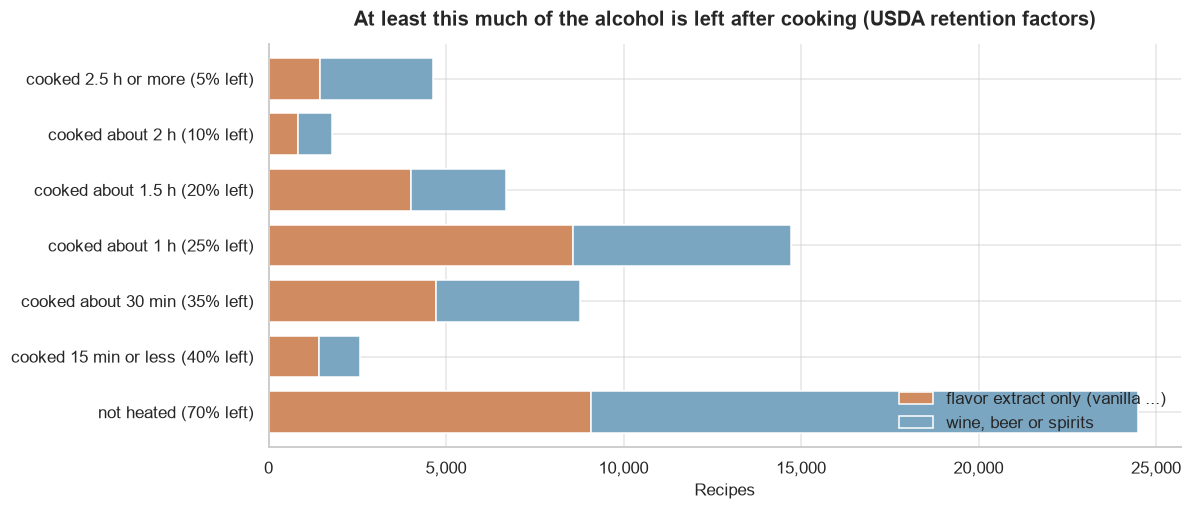

In [13]:
LOWEST_SHARE_LABELS = {0.05: "cooked 2.5 h or more", 0.10: "cooked about 2 h", 0.20: "cooked about 1.5 h",
                       0.25: "cooked about 1 h", 0.35: "cooked about 30 min", 0.40: "cooked 15 min or less",
                       0.70: "not heated"}
kind = alcohol["contains_alcohol"].map({True: "wine, beer or spirits", False: "flavor extract only (vanilla ...)"})
lowest = (pd.crosstab(alcohol["alcohol_left_min"].round(2), kind)
          .reindex(list(LOWEST_SHARE_LABELS)).fillna(0).astype(int))
lowest.index = [f"{LOWEST_SHARE_LABELS[v]} ({v:.0%} left)" for v in lowest.index]

fig, ax = plt.subplots(figsize=(11, 4.8))
lowest.plot.barh(stacked=True, ax=ax, color=["#d08c60", "#7aa6c2"], width=0.75)
ax.invert_yaxis()
ax.set_xlabel("Recipes")
ax.set_ylabel("")
thousands(ax, axis="x")
ax.legend(title="", loc="lower right")
ax.set_title("At least this much of the alcohol is left after cooking (USDA retention factors)")
show_figure(fig, "nb02_06_alcohol_left")

---

## 6. Save the Labels

One row per recipe, joined to notebook 01's tables by `recipe_id`; `split` is copied so the models in section 7 use exactly the same train / validation / test recipes (no leakage). The file goes to `data/interim/` because the model predictions will be added to it.

In [14]:
LABEL_COLUMNS = ["recipe_id", "split", "source", "methods_instructions", "methods_tags", "has_instructions",
                 "has_tags", "fried_by_name", "cooking_fats", "fat_specific", "frying_fat_unknown",
                 "alcohol_left_min", "alcohol_left_max"]
COOKING_LABELS_OUT = "data/interim/recipe_cooking_labels.parquet"
labels[LABEL_COLUMNS].to_parquet(COOKING_LABELS_OUT, index=False)
print(f"Saved {len(labels):,} rows x {len(LABEL_COLUMNS)} columns to {COOKING_LABELS_OUT} "
      f"({os.path.getsize(COOKING_LABELS_OUT) / 1e6:.1f} MB)")

Saved 291,755 rows x 13 columns to data/interim/recipe_cooking_labels.parquet (2.7 MB)


---

## 7. Next Steps: the Two Models

**7.1 Cooking-method model.** Learns the methods from the recipe **name and ingredients**, trained on the labels above (tags and rules), so it can label the 73,000 CulinaryDB and Hugging Face recipes that have no instructions. Checked on the validation split and on a blind hand-checked sample, like the restriction flags.

**7.2 Likely-fat model.** Trained on recipes that name a specific fat; predicts the 3 most likely fats (with probabilities) for recipes that say only "oil" or nothing, from the cuisine, country, ingredients and cooking method. Its output is always shown as **"likely, not verified"**.

**7.3 Cautions.** New columns for the agents: `frying_fat_unknown`, `may_contain_peanut_oil` and `may_contain_animal_fat` (when the fat is unknown and the likely-fat model ranks one of those), and `shared_fryer_risk` for deep-fried dishes from restaurants.

**Known limits**

- The recipes come mostly from English-language sites, so butter and olive oil are over-represented: India's top fat here is sunflower oil, not ghee or mustard oil. The likely-fat model will learn this bias; the reference table's `traditional_in` column is the counterweight.
- Food.com tags are optional and added by the recipe's author, so a missing tag is not a "no".
- Smoke points vary with refining and are shown as ranges.